<a href="https://colab.research.google.com/github/almabaconawa/Data-Analytics-projects/blob/main/Simple_Linear_regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Q1. Load the `mtcars` dataset from the `statsmodels` package and provide summary statistics for all variables.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Load the dataset
mtcars = sm.datasets.get_rdataset("mtcars").data

# Summary statistics
print(mtcars.describe())


             mpg        cyl        disp          hp       drat         wt  \
count  32.000000  32.000000   32.000000   32.000000  32.000000  32.000000   
mean   20.090625   6.187500  230.721875  146.687500   3.596563   3.217250   
std     6.026948   1.785922  123.938694   68.562868   0.534679   0.978457   
min    10.400000   4.000000   71.100000   52.000000   2.760000   1.513000   
25%    15.425000   4.000000  120.825000   96.500000   3.080000   2.581250   
50%    19.200000   6.000000  196.300000  123.000000   3.695000   3.325000   
75%    22.800000   8.000000  326.000000  180.000000   3.920000   3.610000   
max    33.900000   8.000000  472.000000  335.000000   4.930000   5.424000   

            qsec         vs         am       gear     carb  
count  32.000000  32.000000  32.000000  32.000000  32.0000  
mean   17.848750   0.437500   0.406250   3.687500   2.8125  
std     1.786943   0.504016   0.498991   0.737804   1.6152  
min    14.500000   0.000000   0.000000   3.000000   1.0000  
2

### Q2. Check for missing values in the dataset.

In [ ]:
print(mtcars.isnull().sum())
# Answer: No missing values in mtcars.


mpg     0
cyl     0
disp    0
hp      0
drat    0
wt      0
qsec    0
vs      0
am      0
gear    0
carb    0
dtype: int64


### Q3. What are the range, mean, and median of the `mpg` variable?

In [ ]:
print("MPG Range:", (mtcars['mpg'].min(), mtcars['mpg'].max()))
print("Mean MPG:", mtcars['mpg'].mean())
print("Median MPG:", mtcars['mpg'].median())


MPG Range: (10.4, 33.9)
Mean MPG: 20.090625000000003
Median MPG: 19.2


### Q4. Create a scatterplot of `mpg` against `wt`. Add a title and axis labels to your plot.

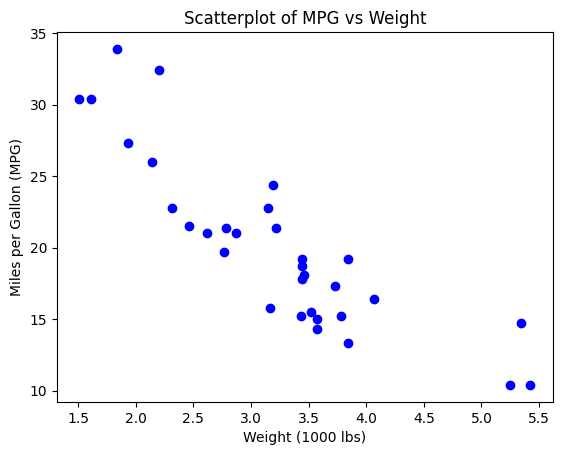

In [ ]:
plt.scatter(mtcars['wt'], mtcars['mpg'], color="blue")
plt.title("Scatterplot of MPG vs Weight")
plt.xlabel("Weight (1000 lbs)")
plt.ylabel("Miles per Gallon (MPG)")
plt.show()


### Q5. Create a boxplot of `mpg` grouped by the number of cylinders (`cyl`).

/tmp/ipython-input-4117038710.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cyl", y="mpg", data=mtcars, palette="Set2")


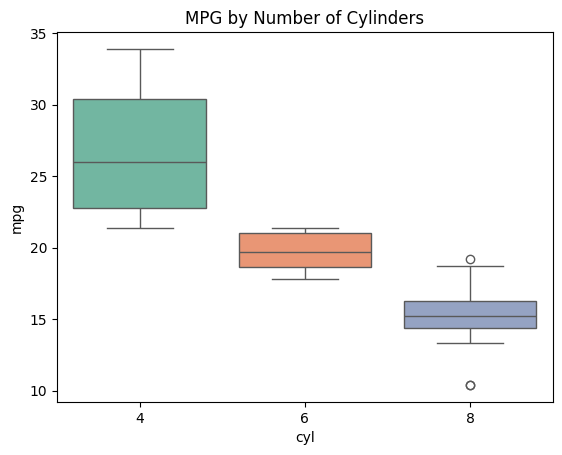

In [ ]:
sns.boxplot(x="cyl", y="mpg", data=mtcars, palette="Set2")
plt.title("MPG by Number of Cylinders")
plt.show()


### Q6. Create pairwise scatterplots among `mpg`, `wt`, `hp`, and `qsec`.

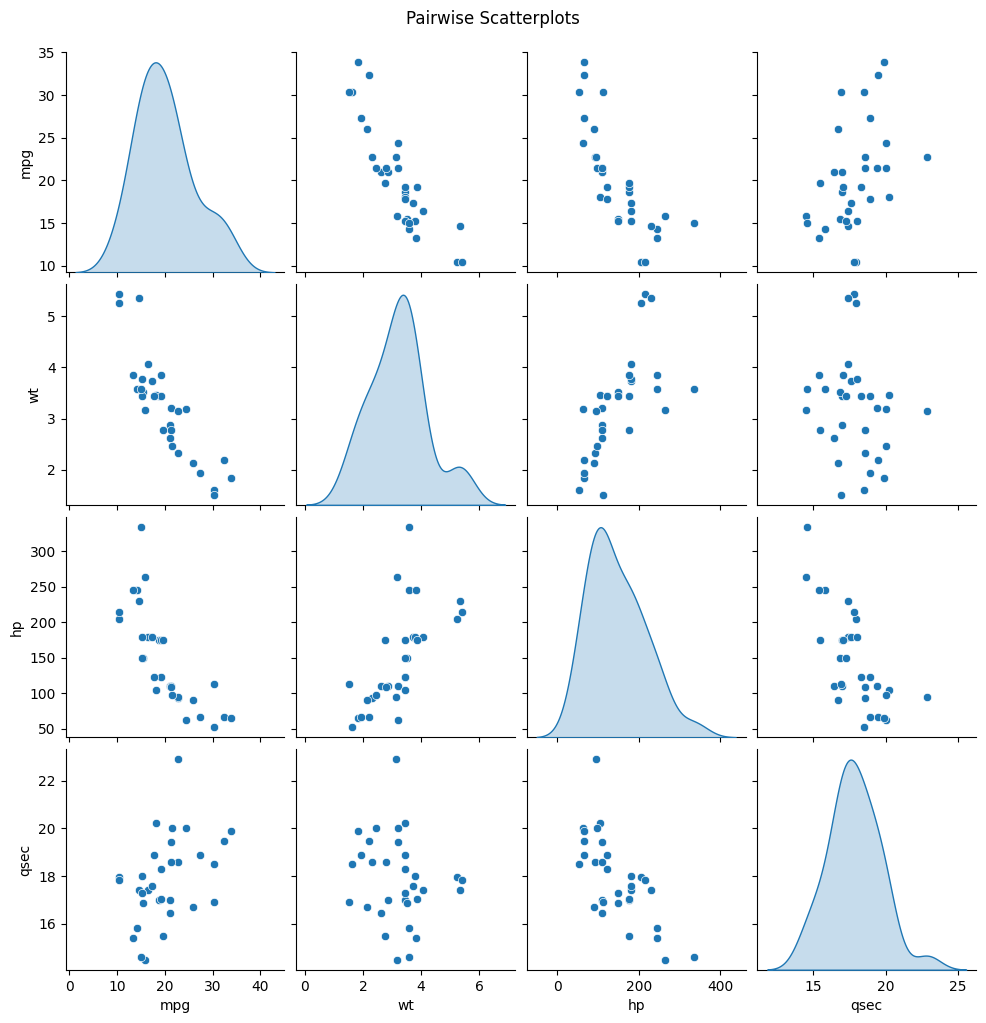

In [ ]:
sns.pairplot(mtcars[["mpg", "wt", "hp", "qsec"]], diag_kind="kde")
plt.suptitle("Pairwise Scatterplots", y=1.02)
plt.show()


### Q7. Fit a simple linear regression model with `mpg` as the response and `wt` as the predictor. Display a summary of the model. Interpret the coefficients of the linear model. How does weight (`wt`) affect miles per gallon (`mpg`)?

In [ ]:
model = smf.ols("mpg ~ wt", data=mtcars).fit()
print(model.summary())
plt.show()



                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     91.38
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           1.29e-10
Time:                        00:17:56   Log-Likelihood:                -80.015
No. Observations:                  32   AIC:                             164.0
Df Residuals:                      30   BIC:                             167.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     37.2851      1.878     19.858      0.0

In [ ]:
model_mult = smf.ols("mpg ~ wt + hp + qsec", data=mtcars).fit()
print(model_mult.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     47.15
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           4.51e-11
Time:                        00:32:36   Log-Likelihood:                -73.571
No. Observations:                  32   AIC:                             155.1
Df Residuals:                      28   BIC:                             161.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     27.6105      8.420      3.279      0.0

### Q8. Create a scatterplot of `mpg` vs `wt` with the regression line added.

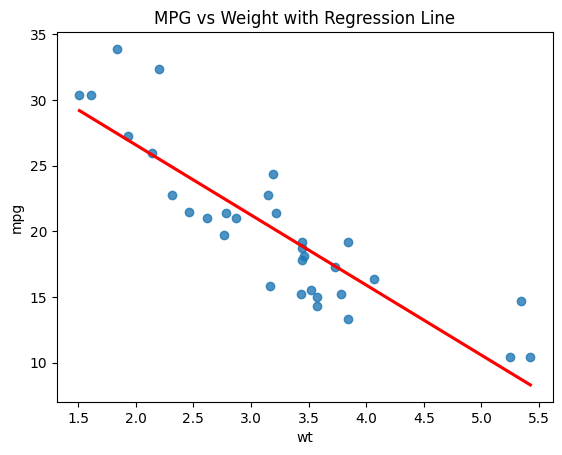

In [ ]:
sns.regplot(x="wt", y="mpg", data=mtcars, ci=None, line_kws={"color":"red"})
plt.title("MPG vs Weight with Regression Line")
plt.show()


### Q9. Plot the residuals from the simple linear regression model against `wt`.

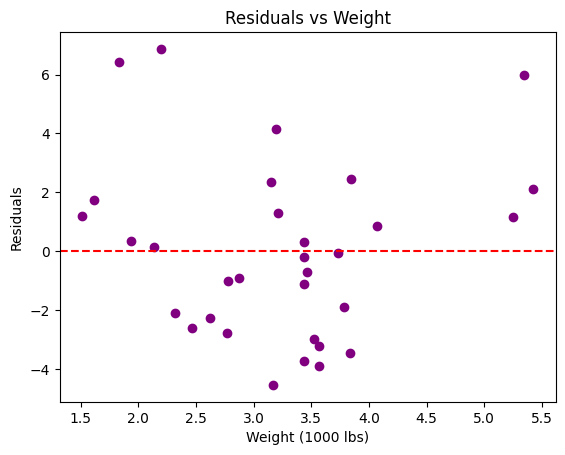

In [ ]:
residuals = model.resid
plt.scatter(mtcars['wt'], residuals, color="purple")
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs Weight")
plt.xlabel("Weight (1000 lbs)")
plt.ylabel("Residuals")
plt.show()


### Q10. Predict the `mpg` for a car with a weight of 3000 lbs (`wt=3`).

In [ ]:
new_data = pd.DataFrame({"wt":[3]})
print("Predicted MPG for wt=3:", model.predict(new_data)[0])


Predicted MPG for wt=3: 21.251711449174017


### Q11. What are the R-squared and Adjusted R-squared values for this model?

In [ ]:
print("R-squared:", model.rsquared)
print("Adjusted R-squared:", model.rsquared_adj)


R-squared: 0.7528327936582646
Adjusted R-squared: 0.7445938867802067


### Q12. Fit a multiple linear regression model with `mpg` as the response and `wt`, `hp`, and `qsec` as predictors. Interpret the coefficients of each predictor in the model. How do weight (wt), horsepower (hp), and quarter-mile time (qsec) affect miles per gallon (mpg)?

In [ ]:
model_mult = smf.ols("mpg ~ wt + hp + qsec", data=mtcars).fit()
print(model_mult.summary())

# Intercept: The expected mpg when wt, hp, and qsec are all 0. This is theoretical since those values cannot all be 0 in practice.
# Weight (wt): For each additional 1000 lbs, the mpg decreases by the coefficient value of wt. This indicates that heavier cars tend to have lower fuel efficiency, holding hp and qsec constant.
# Horsepower (hp): For each additional unit of horsepower, the mpg decreases by the coefficient value of hp. Higher horsepower typically leads to higher fuel consumption.
# Quarter-mile time (qsec): For each additional second it takes to complete the quarter-mile, the mpg increases by the coefficient value of qsec. This indicates that cars with slower acceleration times may be more fuel-efficient.

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     47.15
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           4.51e-11
Time:                        00:21:32   Log-Likelihood:                -73.571
No. Observations:                  32   AIC:                             155.1
Df Residuals:                      28   BIC:                             161.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     27.6105      8.420      3.279      0.0

### Q13. Predict the `mpg` for a car with `wt=3`, `hp=150`, and `qsec=18`.

In [ ]:
new_data2 = pd.DataFrame({"wt":[3], "hp":[150], "qsec":[18]})
print("Predicted MPG:", model_mult.predict(new_data2)[0])


Predicted MPG: 21.055801013295657


### Q14. Find cars in the dataset with `wt` between 2.5 and 3.5, `hp` between 120 and 180, and `qsec` between 17 and 19. Compare their `mpg` with your prediction above.

In [ ]:
similar_cars = mtcars[(mtcars['wt'].between(2.5,3.5)) &
                      (mtcars['hp'].between(120,180)) &
                      (mtcars['qsec'].between(17,19))]
print(similar_cars[['mpg','wt','hp','qsec']])


                    mpg     wt   hp   qsec
rownames                                  
Hornet Sportabout  18.7  3.440  175  17.02
Merc 280           19.2  3.440  123  18.30
Merc 280C          17.8  3.440  123  18.90
AMC Javelin        15.2  3.435  150  17.30
